Stochastic Variational Bayes - example nonlinear model
==============================================

This notebook implements stochastic variational Bayes for a nonlinear model. The model we will use is a bi-exponential model, i.e. we will assume our data reflects a time-dependent signal of the following form:

$$S_{true}(t) = A_1 e^{-R_1t} + A_2 e^{-R_2t}$$

However the actual time dependent signal $S(t)$ will be affected by additive Gaussian noise, so will have the distribution:

$$P(S(t)) = \frac{\sqrt{\beta}}{\sqrt{2\pi}} \exp{\bigg(-\frac{\beta}{2} (S(t) - S_{true}(t))^2}\bigg)$$

Given $S(t)$ our aim will be to infer the values of $A_1$, $A_2$, $R_1$, $R_2$ and $\beta$.

Here's how we can generate some sample data from this model in Python:

In [1]:
import numpy as np
from tqdm.notebook import tqdm_notebook
from matplotlib import pyplot as plt
import torch

%matplotlib inline
# Ground truth parameters
# We infer the precision, BETA, but it is useful to
# derive the variance and standard deviation from it
A1_TRUTH = 10.0
A2_TRUTH = 10.0
R1_TRUTH = 10.0
R2_TRUTH = 1.0
BETA_TRUTH = 1.0
VAR_TRUTH = 1/BETA_TRUTH
STD_TRUTH = np.sqrt(VAR_TRUTH)

# Observed data samples are generated by Numpy from the ground truth
# Gaussian distribution. Reducing the number of samples should make
# the inference less 'confident' - i.e. the output variances for
# MU and BETA will increase
N = 200
T = np.linspace(0, 5, N)


DATA_CLEAN = A1_TRUTH * np.exp(-R1_TRUTH * T) + A2_TRUTH * np.exp(-R2_TRUTH*T)
DATA = DATA_CLEAN + np.random.normal(0, STD_TRUTH, [N])
print("Data samples are:")
print(DATA)

Data samples are:
[ 1.94103595e+01  1.73277897e+01  1.41156491e+01  1.44997861e+01
  1.22232273e+01  1.15431159e+01  1.19100618e+01  9.12027244e+00
  1.05572302e+01  7.08720648e+00  6.58473658e+00  8.95556535e+00
  9.33073242e+00  6.33212503e+00  7.89754180e+00  8.72759624e+00
  4.49519011e+00  6.40397727e+00  7.70799131e+00  5.48625322e+00
  5.94824367e+00  5.15126985e+00  6.19057698e+00  5.42516875e+00
  7.74784625e+00  5.41269958e+00  5.33344881e+00  4.34468382e+00
  4.60551530e+00  4.12209790e+00  4.63678729e+00  5.47066902e+00
  4.36550434e+00  4.01839023e+00  5.19659873e+00  4.34384955e+00
  4.96320725e+00  3.74549239e+00  3.98966829e+00  4.25307525e+00
  3.48841363e+00  2.26070701e+00  2.64241057e+00  3.70924124e+00
  2.34651430e+00  4.15418764e+00  3.03917607e+00  3.62866302e-01
  4.10988254e+00  2.78824356e+00  3.85355979e+00  1.23765797e+00
  5.45210298e+00  2.93946013e+00  3.54363692e+00  2.64758460e+00
  3.47794688e+00  4.04128687e+00  3.47416906e+00  3.65119227e+00
  3.350

We can plot this data to illustrate the true signal (green line) and the measured data (red crosses):

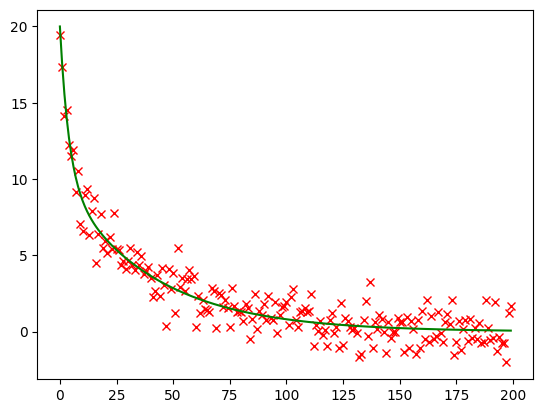

In [2]:
plt.figure()
plt.plot(DATA, "rx")
plt.plot(DATA_CLEAN, "g")
plt.show()

As with the single Gaussian example we will use a multivariate normal distribution as our prior and approximate posterior distributions. 

One difference here is that we will choose to infer the log of the decay rate parameters $R_1$ and $R_2$. This is because if these parameters are allowed to become negative the model prediction will become an exponential growth and can easily lead to numerical errors.

We will still choose our priors to be relatively uninformative as follows:


In [3]:
a0 = 1.0
v0 = 100000.0
r0 = 0.0
u0 = 10.0
b0 = 0.0
w0 = 10.0
print("Priors: Amplitude mean=%f, variance=%f" % (a0, v0))
print("        Log decay rate mean=%f, variance=%f" % (r0, u0))
print("        Log noise variance mean=%f, variance=%f" % (b0, w0))

Priors: Amplitude mean=1.000000, variance=100000.000000
        Log decay rate mean=0.000000, variance=10.000000
        Log noise variance mean=0.000000, variance=10.000000


The posterior will be defined in the same way as for the single Gaussian example, however we need to account for the increased number of parameters we are inferring. We will initialize the posterior with the prior values but with reduced initial variance to prevent problems with generating a representative posterior sample. Remember that the decay rates (and the noise) are being inferred as their log-values so the prior mean of 0 translates into a value of 1.

The code to generate a posterior sample is unchanged except for the number of parameters.

In calculating the reconstruction cost we need to calculate the log likelihood of the data given a set of model parameters. We do this by observing that any difference between the biexponential model prediction (given these parameters) and the actual noisy data must be a result of the Gaussian noise - hence the likelihood is simply the likelihood of drawing these differences from the Gaussian noise distribution:

$$\log P(\textbf{y} | A_1; A_2; r_1; r_2; \beta) = \frac{1}{2} \bigg( N \log \beta - \sum{\frac{(y_n - M_n)^2}{\beta}}\bigg)$$

Here $M_n$ is the model prediction for the nth data point which is calculated by evaluating the biexponential model for the given parameters $A_1$, $A_2$, $r_1$ and $r_2$.

For the latent loss we will again use the analytic expression for the K-L divergence of two MVN distributions with a slight modification to the previous code to account for the different number of parameters (5 vs 2)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

# Number of parameters - 4 for the biexponential + noise
NUM_PARAMS = 4 + 1

data = torch.tensor(DATA, dtype=dtype, device=device)  # shape [N]
prior_means = torch.tensor([a0, r0, a0, r0, b0], dtype=dtype, device=device)  # shape [NUM_PARAMS]
prior_covariance = torch.diag(torch.tensor([v0, u0, v0, u0, w0], dtype=dtype, device=device))  # [P,P]

post_means_init = prior_means.clone()
post_covariance_init = np.identity(NUM_PARAMS, dtype=np.float32)  # [P,P]

# Trainable variational parameters
chol_off_diag = torch.nn.Parameter(
    torch.zeros_like(torch.tensor(post_covariance_init, dtype=dtype, device=device))
)

chol_log_diag = torch.nn.Parameter(
    torch.log(torch.diag(torch.tensor(post_covariance_init, dtype=dtype, device=device)))
)  # [P]

post_means = torch.nn.Parameter(post_means_init)  # [P]

t = torch.tensor(T, dtype=dtype, device=device).reshape(1, -1)  # [1, N]

def cost_fun():
    # Build Cholesky factor for posterior covariance
    # chol_diag = diag(sqrt(exp(chol_log_diag)))
    chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))  # [P,P]

    # lower triangle (including diag) of chol_off_diag
    tril_off = torch.tril(chol_off_diag)  # [P,P]

    # L = chol_diag + tril_off
    post_covariance_chol = chol_diag + tril_off  # [P,P]

    post_covariance = post_covariance_chol.T @ post_covariance_chol  # [P,P]

    S = 5
    N = 200

    # eps ~ N(0, I) 
    eps = torch.randn((NUM_PARAMS, S), dtype=dtype, device=device)

    samples = post_means.view(NUM_PARAMS, 1).expand(NUM_PARAMS, S)

    # post_samples = samples + L @ eps
    post_samples = samples + (post_covariance_chol @ eps)  # [P,S]

    a1 = post_samples[0].reshape(-1, 1)                    # [S,1]
    r1 = torch.exp(post_samples[1].reshape(-1, 1))         # [S,1]
    a2 = post_samples[2].reshape(-1, 1)                    # [S,1]
    r2 = torch.exp(post_samples[3].reshape(-1, 1))         # [S,1]

    log_noise_var = -post_samples[4]                       # [S]
    noise_var = torch.exp(log_noise_var)                   # [S]

    prediction = a1 * torch.exp(-r1 * t) + a2 * torch.exp(-r2 * t)  # [S,N]

    diff = data.view(1, -1) - prediction                   # [S,N]

    sum_square_diff = torch.sum(diff * diff, dim=1)

    log_likelihood = 0.5 * (
        -log_noise_var * torch.tensor(float(N), device=device, dtype=dtype)
        - (sum_square_diff / noise_var)
    )

    reconstr_loss = -torch.mean(log_likelihood)

    # KL term (latent_loss)
    C = post_covariance
    C0 = prior_covariance
    C0_inv = torch.linalg.inv(C0)

    m_minus_m0 = (post_means - prior_means).reshape(-1, 1)  # [P,1]
    m_minus_m0_T = (post_means - prior_means).reshape(1, -1)  # [1,P]

    term1 = torch.trace(C0_inv @ C)

    
    signC, logdetC = torch.linalg.slogdet(C)
    signC0, logdetC0 = torch.linalg.slogdet(C0)
    term2 = -(logdetC - logdetC0)

    term3 = -NUM_PARAMS
    term4 = (m_minus_m0_T @ C0_inv @ m_minus_m0).squeeze()  # scalar

    latent_loss = 0.5 * (term1 + term2 + term3 + term4)

    cost = reconstr_loss


    return cost

Finally we ask PyTorch to minimise the total cost iteratively:

In [5]:
optimizer = torch.optim.Adam([post_means, chol_log_diag, chol_off_diag], lr=1e-2)

cost_history = []
for epoch in tqdm_notebook(range(5000), desc="Epoch:"):
    optimizer.zero_grad()
    loss = cost_fun()
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(epoch, float(loss.detach().cpu()))
    cost_history.append(loss.detach().numpy())

Epoch::   0%|          | 0/5000 [00:00<?, ?it/s]

0 1657.663330078125
100 638.9223022460938
200 331.0960388183594
300 316.7470703125
400 268.1050720214844
500 253.063232421875
600 248.61831665039062
700 229.5480499267578
800 217.58023071289062
900 212.2493133544922
1000 200.50076293945312
1100 180.91928100585938
1200 180.29519653320312
1300 174.80691528320312
1400 162.5740509033203
1500 156.08230590820312
1600 150.1964569091797
1700 147.54580688476562
1800 140.65225219726562
1900 135.30624389648438
2000 128.4886474609375
2100 123.52513122558594
2200 119.2830810546875
2300 116.0822982788086
2400 112.194580078125
2500 109.7173080444336
2600 107.2585678100586
2700 105.56307220458984
2800 104.30332946777344
2900 103.20259857177734
3000 102.39306640625
3100 101.96365356445312
3200 101.57269287109375
3300 101.35218048095703
3400 101.2154312133789
3500 101.10429382324219
3600 101.00308990478516
3700 100.9822769165039
3800 100.93911743164062
3900 100.90204620361328
4000 100.87571716308594
4100 100.89554595947266
4200 100.87832641601562
4300 1

In [6]:
final_means = post_means

# chol_diag = diag(sqrt(exp(chol_log_diag)))
chol_diag = torch.diag(torch.sqrt(torch.exp(chol_log_diag)))
post_covariance_chol = chol_diag + torch.tril(chol_off_diag)

# post_covariance = L^T L
post_covariance = post_covariance_chol.T @ post_covariance_chol

final_covariance = post_covariance

m = final_means.detach().cpu()
C = final_covariance.detach().cpu()

print("Estimate for amp1: %f (variance: %f)" % (m[0].item(), C[0, 0].item()))
print("Estimate for amp2: %f (variance: %f)" % (m[2].item(), C[2, 2].item()))
print("Estimate for r1: %f" % (torch.exp(m[1]).item(),))
print("Estimate for r2: %f" % (torch.exp(m[3]).item(),))
print("Estimate for beta (noise): %f" % (torch.exp(-m[4]).item(),))

Estimate for amp1: 9.736230 (variance: 0.000040)
Estimate for amp2: 9.627014 (variance: 0.000001)
Estimate for r1: 0.950324
Estimate for r2: 9.864421
Estimate for beta (noise): 1.008415


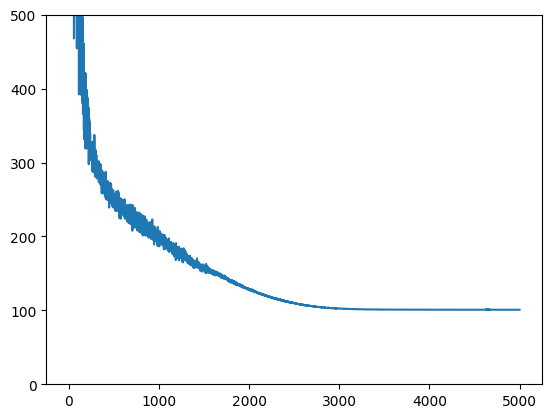

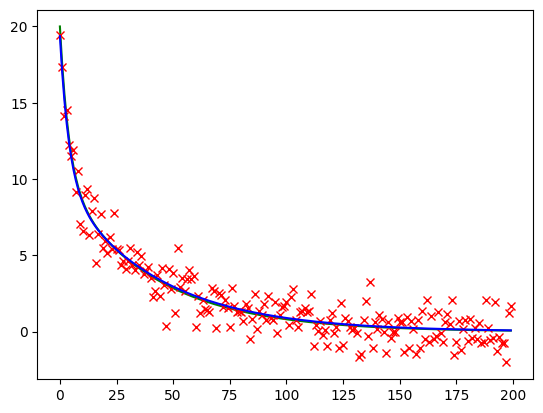

In [7]:
plt.figure()
plt.plot(cost_history)
plt.ylim(0, 500)

plt.figure()
plt.plot(DATA_CLEAN, 'g')
plt.plot(DATA, 'rx')

S = 5

eps = torch.randn((NUM_PARAMS, S), dtype=post_means.dtype, device=post_means.device)

samples = post_means.view(NUM_PARAMS, 1).expand(NUM_PARAMS, S)  # [P,S]

post_samples = samples + (post_covariance_chol @ eps)  # [P,S]

a1 = post_samples[0].reshape(-1, 1)            
r1 = torch.exp(post_samples[1].reshape(-1, 1)) 
a2 = post_samples[2].reshape(-1, 1)            
r2 = torch.exp(post_samples[3].reshape(-1, 1)) 

log_noise_var = -post_samples[4]               
noise_var = torch.exp(log_noise_var)

t = torch.tensor(T, dtype=post_means.dtype, device=post_means.device).reshape(1, -1)  # [1,N]
prediction = a1 * torch.exp(-r1 * t) + a2 * torch.exp(-r2 * t)  # [S,N]

# Plot the first posterior sample prediction
plt.plot(prediction[0].detach().cpu().numpy(), 'b')

plt.show()